# Predictable by Design? Play-Calling Tendency and Offensive Efficiency in the 2025 NFL Season

**MSc Data Science - DSM050 Data Visualisation - Final Coursework**

Dataset: nflverse / nflfastR play-by-play, 2025 NFL season. Repository: *[https://github.com/je-star14/DSM050-NFL]*

## Introduction

American football is a sport of discrete, observable decisions. Before every snap a coordinator chooses to run or pass and chooses where to attack, and because the game stops between plays each decision is recorded separately. That makes the sport unusually well suited to studying tendency based off offensive formation, personnel, field position alongside down and distance.

Tendency matters because it is exploitable. A defence that anticipates the call gains an advantage before the ball moves, so from a coaching standpoint predictability is a flaw, the aim is to keep the defense guessing - forcing them to be reactive rather than proactive. This assumption is rarely quantified, and it contains a claim: that unpredictability causes efficiency. That claim is game theory's minimax prediction: in a zero-sum game the equilibrium strategy is mixed, so a predictable caller can be exploited. Testing it on 125,000 NFL plays, Kovash and Levitt found teams pass less than equilibrium implies and alternate between run and pass more than randomness would produce [1]. 

This report tests that claim using every run and pass from the 2025 NFL regular season: where teams attack, how much of what they do is dictated by situation, how predictable each team is once situation is accounted for, whether predictability carries a cost, and whether offenses fall into stylistic types.

Five findings emerge. Usage and productivity are close to inverted: the most-used passing zone is the least productive. Play-calling is overwhelmingly a response to situation rather than identity, so any measure of style must condition on situation first. Once it does, only the two extreme offenses are separable, and the rest are statistically indistinguishable. The association between unpredictability and efficiency does not survive varying the specification. And offensive identity is continuous rather than categorical, yet its strongest dimension correlates with efficiency.

Every comparison is shown with an interval rather than a point, because the central fact of this data is that football outcomes are dominated by play-to-play variance.

## Research Topic

### Motivation and Objectives

The goal is to define offensive tendencies and evaluate whether they drive performance. However, a core analytical challenge lies in disentangling a team's true preference from situational constraints, for example a trailing team passing on every down reflects tactical necessity, not stylistic identity.

### Key Concepts

**Expected Points Added (EPA)** is the change in a team's expected points across a play, given down, distance, field position and time. It is the standard efficiency currency in public football analytics because it values a play by its effect on scoring rather than by raw yardage. EPA is not observed: it is the output of a model fitted by the nflfastR project and inherits that model's assumptions [2].

**Success rate**, the proportion of plays with positive EPA, is a blunter but more robust companion insensitive to the long tail of explosive plays. **Expected pass rate 'xpass'** is a second nflfastR model giving the probability a situation produces a pass; actual minus expected is **pass rate over expectation (PROE)**.

**Situational entropy** is introduced here to quantify predictability. For a team in a given situation, the binary entropy of its pass rate *p* is H(p) = −p·log₂(p) − (1−p)·log₂(1−p), equal to 1 bit when the team is a coin flip and falling toward 0 as the call becomes certain. Averaging H across situations, weighted by frequency, gives one number: high entropy means a defence learns little from the situation. Predictability is a question of information, and Shannon entropy is its canonical quantification [3].

### Research Questions

1. Where does the league attack, and does usage align with productivity?
2. How much of play-calling is determined by situation rather than by team identity?
3. Once situation is controlled, how predictable is each offense, and are teams meaningfully distinguishable from one another?
4. Does unpredictability carry a measurable efficiency benefit?
5. Do offenses separate into stylistic archetypes, and does position within tendency space relate to how well an offense performs?

RQ5 is answered with a dimensionality-reduction and cluster-validation approach drawn from Topic 9, and uncertainty quantification from Topic 10 is applied throughout RQ3, RQ4 and RQ5.

In [16]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RNG = np.random.default_rng(42)

# Figure style: sparse gridlines, no top/right spines, left-aligned titles.
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E8E8E8", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False,
})
# Palette. The three categorical hues are checked for colour-vision separation and
# contrast against the page rather than chosen by eye.
INK, MUTED, GRID = "#1F2933", "#8A9199", "#E8E8E8"
COOL, ACCENT, THIRD = "#2a78d6", "#eb6834", "#4a3aa7"
SEQ = ["#e8f1fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#0d366b"]
DIVERGING = "RdBu_r"
ZL = ["left", "middle", "right"]

# Field geometry, in yards. Used by every zone map so they share one coordinate system.
FIELD_W, DEEP_LINE, FIELD_TOP = 53.3, 15.0, 38.0
X_EDGES = [0, FIELD_W / 3, 2 * FIELD_W / 3, FIELD_W]
Y_EDGES = [0, DEEP_LINE, FIELD_TOP]

def draw_field(ax, over=False):
    """Field markings. Called once under the zone fills, and again over them so the
    yard lines and hashes stay visible through the colour."""
    col = "white" if over else GRID
    a, z = (0.55, 5) if over else (1.0, 1)
    if not over:
        ax.add_patch(mpl.patches.Rectangle((0, 0), FIELD_W, FIELD_TOP,
                                           facecolor="white", edgecolor="none", zorder=0))
    for y in range(5, int(FIELD_TOP) + 1, 5):
        ax.plot([0, FIELD_W], [y, y], color=col, lw=0.8, alpha=a, zorder=z)
    for y in range(1, int(FIELD_TOP)):
        if y % 5:
            for x in (FIELD_W * 0.33, FIELD_W * 0.67):
                ax.plot([x - 0.6, x + 0.6], [y, y], color=col, lw=0.7, alpha=a, zorder=z)
    if over:
        return
    for y in range(5, int(FIELD_TOP) + 1, 5):
        ax.text(-1.2, y, str(y), ha="right", va="center", fontsize=7, color=MUTED)
    ax.set_xlim(-6, FIELD_W + 1)
    ax.set_ylim(-3.5, FIELD_TOP + 1)
    ax.set_aspect("equal")
    ax.axis("off")

def zone_map(ax, matrix, fmt, title, cmap, vlim=None, note=None):
    """Fill the six passing zones on a drawn field, labelling each with its value."""
    draw_field(ax)
    v = matrix.values
    lim = vlim or np.nanmax(np.abs(v))
    norm = (mpl.colors.TwoSlopeNorm(vcenter=0, vmin=-lim, vmax=lim) if cmap == DIVERGING
            else mpl.colors.Normalize(0, lim))
    cm = (plt.get_cmap(cmap) if cmap == DIVERGING
          else mpl.colors.LinearSegmentedColormap.from_list("seq", SEQ))
    rows = ["deep", "short"]                                 # matrix row order
    for r, row in enumerate(rows):
        y0, y1 = (DEEP_LINE, FIELD_TOP) if row == "deep" else (0, DEEP_LINE)
        for c in range(3):
            x0, x1 = X_EDGES[c], X_EDGES[c + 1]
            val = v[r, c]
            face = cm(norm(val))
            ax.add_patch(mpl.patches.Rectangle(
                (x0 + 0.25, y0 + 0.25), (x1 - x0) - 0.5, (y1 - y0) - 0.5,
                facecolor=face, edgecolor="white", lw=2, zorder=2, alpha=0.92))
            lum = 0.299 * face[0] + 0.587 * face[1] + 0.114 * face[2]
            ax.text((x0 + x1) / 2, (y0 + y1) / 2, fmt.format(val), ha="center", va="center",
                    fontsize=13, fontweight="bold",
                    color="white" if lum < 0.55 else INK, zorder=3)
    draw_field(ax, over=True)
    ax.plot([0, FIELD_W], [0, 0], color=INK, lw=2.4, zorder=6)
    ax.text(-1.2, 0, "LOS", ha="right", va="center", fontsize=7.5,
            color=INK, fontweight="bold")
    ax.plot([0, FIELD_W], [DEEP_LINE, DEEP_LINE], color=INK, lw=1.0,
            ls=(0, (4, 3)), zorder=6)
    for c, lab in enumerate(ZL):
        ax.text((X_EDGES[c] + X_EDGES[c + 1]) / 2, -2.2, lab, ha="center", va="center",
                fontsize=8.5, color=MUTED)
    ax.set_title(title)
    if note:
        ax.text(FIELD_W, FIELD_TOP + 0.4, note, ha="right", va="bottom",
                fontsize=7.5, color=MUTED)

from pathlib import Path
FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

def show(fig, name):
    """Save each figure to figures/ at print resolution, then display it."""
    fig.savefig(FIGDIR / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.show()

def set_ticks(ax, axis, positions, labels=None, **kw):
    """Tick placement that works on matplotlib 3.4 as well as current releases."""
    getattr(ax, f"set_{axis}ticks")(positions)
    if labels is not None:
        getattr(ax, f"set_{axis}ticklabels")(labels, **kw)

def r_ci(a, b, n=4000):
    """Pearson correlation with a bootstrap confidence interval."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    reps = [np.corrcoef(a[i], b[i])[0, 1]
            for i in (RNG.integers(0, len(a), len(a)) for _ in range(n))]
    lo, hi = np.quantile(reps, [0.025, 0.975])
    return np.corrcoef(a, b)[0, 1], lo, hi

import sys, sklearn
print(f"python {sys.version.split()[0]} | pandas {pd.__version__} | "
      f"numpy {np.__version__} | matplotlib {mpl.__version__} | sklearn {sklearn.__version__}")

python 3.7.3 | pandas 1.3.5 | numpy 1.21.6 | matplotlib 3.5.3 | sklearn 1.0.2


## Data Collection / Survey Design

### Provenance

The data is the nflverse play-by-play release for the 2025 NFL season. The analysis reads a local copy of that release held in the repository rather than fetching it at run time. Fixing the file means the exact data behind every figure is version-controlled and cannot shift if the upstream release is later revised; the cost is that the copy has to be trusted, so its origin is recorded in full.

Two layers sit behind the file. Plays are recorded live by the NFL's in-stadium statisticians and published through the league's public GameCenter feed, the same feed behind official box scores. The nflfastR project parses that feed, standardises it, and adds modelled quantities including expected points added and expected pass rate. The file used here is the 2025 season release, downloaded unmodified. [2]

The release holds 48,771 plays across 372 columns, covering all 285 games of 2025. Only thirty-one columns are used here, most of the rest being cumulative running totals, so the analysis subset is written back to the repository at about 1.5 MB compressed. That submits the data alongside the notebook without committing a 115 MB file.

### Ethical and Legal Considerations

The data concerns professional athletes in public, salaried employment. It holds no personal or sensitive information and no expectation of privacy, and nflverse distributes it openly for non-commercial use. The one ethical consideration is representational: player-level metrics built from team-level events misattribute credit, so this report makes only team-level claims.

### Critical Evaluation Of The Source

The descriptive fields - down, distance, play type, run direction, pass zone - are recorded by league statisticians in real time and are as trustworthy as any public sports dataset.

The modelled fields must not be treated as observations. 'epa', 'success' and 'xpass' are estimates from nflfastR's own fitted models, embedding choices about model form, training window and features that a user cannot inspect from the data alone. Treating EPA as though it were measured is the central trap in public football analytics; this report treats it as a defensible summary, not ground truth.

Three limitations constrain what can be asked. There is no personnel information, so formation groupings cannot be studied; no coverage assignment, so defensive backs cannot be evaluated individually; and pressure is only partly captured, since hits and sacks are recorded but not hurries, understating true pressure by more than half.

## Data overview and pre-processing

The analysis frame is built by explicit filters, each a modelling decision rather than a cleaning step. Post-season games are excluded because the participating teams are a biased sample. Special-teams plays, no-plays and timeouts go with the restriction to run or pass, which also removes kneels and spikes. Plays with no recorded down or team are dropped.

In [17]:
# Local copy of the nflverse 2025 release. The tidy location is data/raw/, but the file is
# accepted next to the notebook too, so this runs from a fresh checkout or a flat folder.
CANDIDATE_PATHS = [
    Path("data/raw/pbp-2025.csv"),
    Path("pbp-2025.csv"),
    Path("data/pbp-2025.csv"),
]

# On Python 3.9 or newer the same file can be regenerated from source with:
#     import nflreadpy
#     nflreadpy.load_pbp([2025]).to_pandas().to_csv("data/raw/pbp-2025.csv", index=False)
# nflreadpy does not support Python 3.7, so the committed copy is the documented path.

season_path = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if season_path is None:
    raise FileNotFoundError(
        "Could not find the season CSV. Looked for:\n  "
        + "\n  ".join(str(p) for p in CANDIDATE_PATHS)
        + f"\nWorking directory: {Path.cwd()}"
        + "\nPut pbp-2025.csv in one of those places and re-run this cell."
    )

raw = pd.read_csv(season_path, low_memory=False)
print(f"Source: local copy of the nflverse 2025 release ({season_path})")
print(f"Loaded: {len(raw):,} plays x {raw.shape[1]} columns")

Source: local copy of the nflverse 2025 release (data/raw/pbp-2025.csv)
Loaded: 48,771 plays x 372 columns


The columns the analysis uses are defined below, then written back to the repository so the data behind every figure is version-controlled.

In [18]:
KEEP = ["play_id", "game_id", "season", "week", "season_type", "game_date", "posteam", "defteam",
        "posteam_type", "qtr", "down", "ydstogo", "yardline_100", "score_differential",
        "play_type", "shotgun", "no_huddle", "qb_kneel", "qb_spike", "pass_attempt",
        "rush_attempt", "pass_length", "pass_location", "air_yards", "yards_gained",
        "run_location", "run_gap", "epa", "xpass", "success", "first_down"]

pbp = raw[[c for c in KEEP if c in raw.columns]].copy()

OUT = Path("data/processed")
OUT.mkdir(parents=True, exist_ok=True)
subset_path = OUT / "pbp_2025_analysis_subset.csv.gz"
pbp.to_csv(subset_path, index=False, compression="gzip")
print(f"Analysis subset written to {subset_path} "
      f"({subset_path.stat().st_size / 1e6:.1f} MB, {pbp.shape[1]} columns)")

steps = []
def log(name, frame):
    steps.append((name, len(frame)))
    return frame

cur = log("All rows in release", pbp)
cur = log("Regular season", cur[cur.season_type == "REG"])
cur = log("Run or pass play", cur[cur.play_type.isin(["run", "pass"])])
plays = log("Known down and team", cur[cur.down.notna() & cur.posteam.notna()]).copy()

# Verify rather than assume that kneels and spikes are already gone.
assert ((plays.qb_kneel == 1) | (plays.qb_spike == 1)).sum() == 0

plays["is_pass"] = plays["pass_attempt"].fillna(0).astype(int)
plays["under_centre"] = 1 - plays["shotgun"].fillna(0)

passes = plays[(plays.is_pass == 1) & plays.pass_length.notna()
               & plays.pass_location.notna()].copy()
runs = plays[(plays.rush_attempt == 1) & plays.run_location.notna()].copy()

for n, v in steps:
    print(f"{n:<24}{v:>7,}")
print(f"{'Targets with a zone':<24}{len(passes):>7,}")
print(f"{'Runs with a direction':<24}{len(runs):>7,}")
print(f"{'Teams / weeks':<24}{plays.posteam.nunique()} teams, weeks "
      f"{int(plays.week.min())}-{int(plays.week.max())}")

Analysis subset written to data/processed/pbp_2025_analysis_subset.csv.gz (1.5 MB, 31 columns)
All rows in release      48,771
Regular season           46,452
Run or pass play         32,937
Known down and team      32,814
Targets with a zone      17,359
Runs with a direction    14,075
Teams / weeks           32 teams, weeks 1-18


Two features of the data matter before any figure is read, and both are properties of the sport rather than defects in the file. Roughly 27% of carries have no `run_gap` value: a run up the middle has no left-or-right gap, so imputing it would invent a distinction the sport does not make. Second, the variables this study needs are essentially complete.

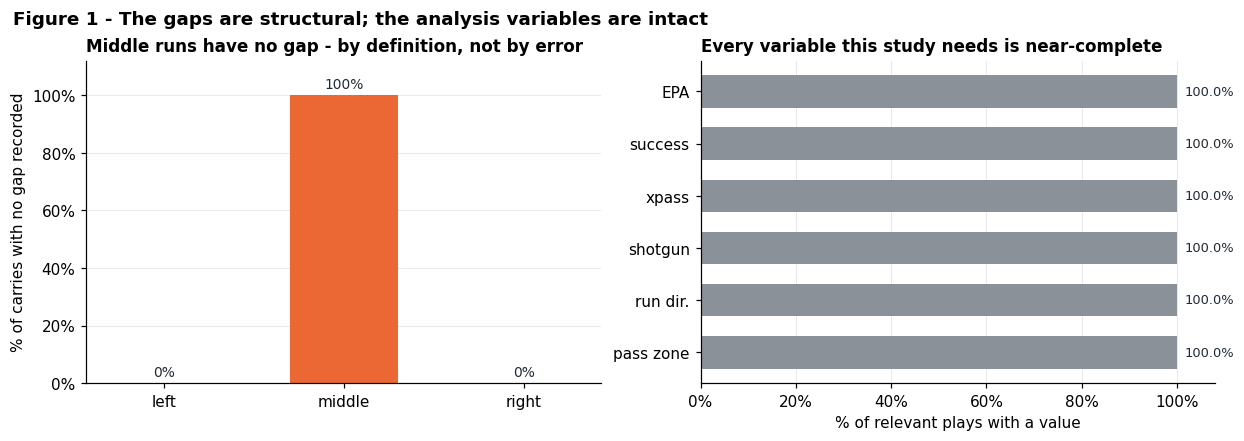

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.9), constrained_layout=True)

ax = axes[0]
gapmiss = (runs.groupby("run_location", observed=True).run_gap
           .apply(lambda s: s.isna().mean() * 100).reindex(ZL))
ax.bar(gapmiss.index, gapmiss.values, color=[COOL, ACCENT, COOL], width=0.6)
for i, v in enumerate(gapmiss.values):
    ax.text(i, v + 2.5, f"{v:.0f}%", ha="center", fontsize=9, color=INK)
ax.set_ylim(0, 112)
ax.set_ylabel("% of carries with no gap recorded")
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter())
ax.set_title("Middle runs have no gap - by definition, not by error")
ax.grid(axis="x", visible=False)

ax = axes[1]
cov = pd.Series({
    "EPA": plays.epa.notna().mean(), "success": plays.success.notna().mean(),
    "xpass": plays.xpass.notna().mean(), "shotgun": plays.shotgun.notna().mean(),
    "run dir.": runs.run_location.notna().mean(),
    "pass zone": (passes.pass_length.notna() & passes.pass_location.notna()).mean(),
}) * 100
ax.barh(cov.index[::-1], cov.values[::-1], color=MUTED, height=0.62)
ax.set_xlim(0, 108)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter())
ax.set_xlabel("% of relevant plays with a value")
ax.set_title("Every variable this study needs is near-complete")
ax.grid(axis="y", visible=False)
for i, v in enumerate(cov.values[::-1]):
    ax.text(v + 1.5, i, f"{v:.1f}%", va="center", fontsize=8.5, color=INK)

fig.suptitle("Figure 1 - The gaps are structural; the analysis variables are intact",
             x=0.005, ha="left", fontweight="bold", fontsize=12)
show(fig, "figure1_data_quality")

In [20]:
# The filter audit is four numbers; a table carries them better than a chart.
audit = pd.DataFrame(steps, columns=["step", "plays retained"])
audit["removed"] = -audit["plays retained"].diff().fillna(0).astype(int)
audit

,step,plays retained,removed
0,All rows in release,48771,0
1,Regular season,46452,2319
2,Run or pass play,32937,13515
3,Known down and team,32814,123


In [21]:
# Run and pass compared on the two things that matter for what follows: the average
# return, and how much that average hides.
summary = (plays.assign(call=np.where(plays.is_pass == 1, "pass", "run"))
                .groupby("call")
                .agg(plays=("epa", "size"), mean_epa=("epa", "mean"),
                     sd_epa=("epa", "std"), success=("success", "mean"))
                .reindex(["run", "pass"]))
summary.round(3)

,plays,mean_epa,sd_epa,success
call,,,,
run,14168,-0.006,1.017,0.430
pass,18646,0.018,1.605,0.447


The filters remove 15,957 plays, roughly a third of the file, 13,515 of them from restricting to runs and passes alone. Nothing is discarded on grounds of quality. The final frame holds 32,814 plays: 17,359 targets with a recorded zone and 14,075 carries with a direction, across 32 teams and 18 weeks.

The summary table shows the asymmetry motivating the rest of the report: passing produces higher mean EPA than running but carries far more variance, and both figures are small in absolute terms.

## Analysis and results

### RQ1 - Where does the league attack, and does usage follow productivity?

The passing game is described by the nine-cell grid nflfastR records: three lateral zones crossed with a short/deep split at fifteen air yards. Running is described by direction and, where one exists, gap.

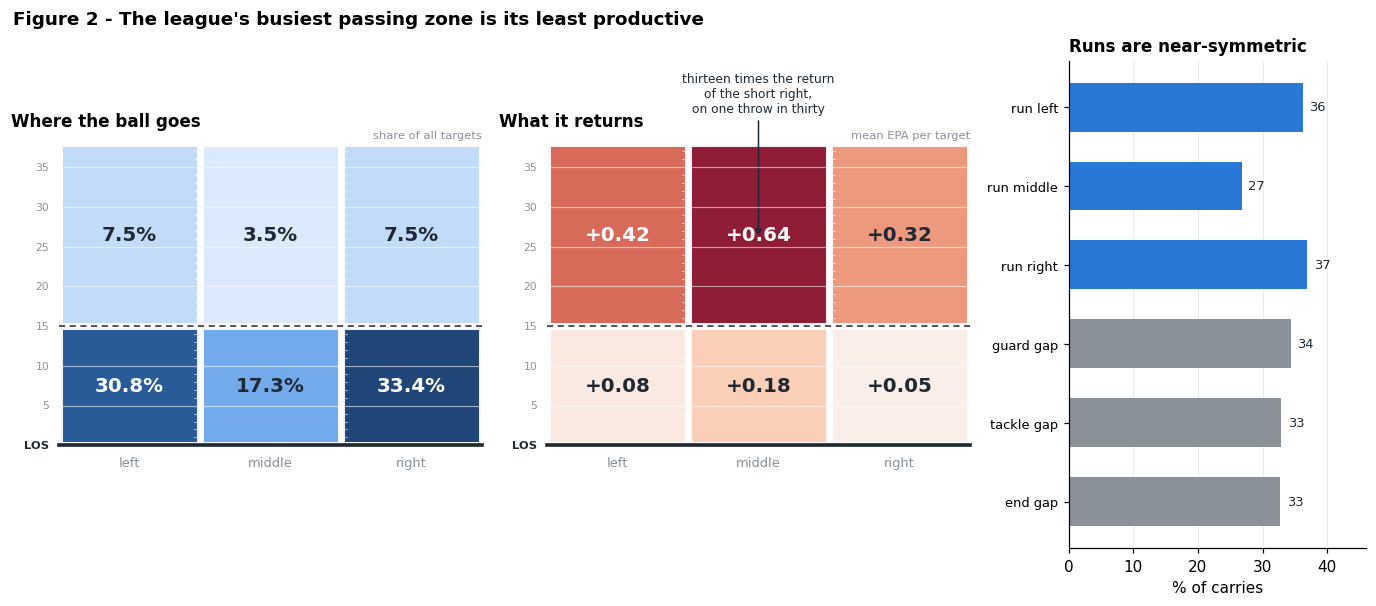

In [22]:
zone = pd.crosstab(passes.pass_length, passes.pass_location,
                   normalize="all").reindex(index=["deep", "short"], columns=ZL) * 100
zepa = passes.pivot_table(index="pass_length", columns="pass_location", values="epa",
                          aggfunc="mean").reindex(index=["deep", "short"], columns=ZL)

fig = plt.figure(figsize=(12.4, 5.4), constrained_layout=True)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.62])

zone_map(fig.add_subplot(gs[0]), zone, "{:.1f}%",
         "Where the ball goes", "seq", note="share of all targets")
ax_epa = fig.add_subplot(gs[1])
zone_map(ax_epa, zepa, "{:+.2f}", "What it returns", DIVERGING,
         vlim=0.7, note="mean EPA per target")
ax_epa.annotate("thirteen times the return\nof the short right,\non one throw in thirty",
                xy=(FIELD_W / 2, DEEP_LINE + 11), xytext=(FIELD_W / 2, FIELD_TOP + 4),
                ha="center", fontsize=8, color=INK,
                arrowprops=dict(arrowstyle="-|>", color=INK, lw=1))

ax = fig.add_subplot(gs[2])
rl = runs.run_location.value_counts(normalize=True).reindex(ZL) * 100
rg = runs.run_gap.value_counts(normalize=True).reindex(["guard", "tackle", "end"]) * 100
y = np.arange(6)[::-1]
vals = list(rl.values) + list(rg.values)
labs = [f"run {x}" for x in ZL] + [f"{x} gap" for x in ["guard", "tackle", "end"]]
ax.barh(y, vals, color=[COOL] * 3 + [MUTED] * 3, height=0.62)
set_ticks(ax, "y", y, labs, fontsize=8.5)
ax.set_xlim(0, 46)
ax.set_xlabel("% of carries")
ax.set_title("Runs are near-symmetric")
ax.grid(axis="y", visible=False)
for yi, v in zip(y, vals):
    ax.text(v + 1, yi, f"{v:.0f}", va="center", fontsize=8.5, color=INK)

fig.suptitle("Figure 2 - The league's busiest passing zone is its least productive",
             x=0.005, ha="left", fontweight="bold", fontsize=12)
show(fig, "figure2_league_map")

Usage and productivity are close to inverted. A third of all targets (33.4%) go short and right, and that zone returns the lowest average on the field at +0.05 EPA. The deep middle is +0.64 EPA per target, roughly thirteen times the return, on just 3.5% of throws. Every deep zone outperforms every short zone, and the two most-used zones are the two least productive possibly capturing low risk check-downs and quick game passes to avoid pressure.

The naive reading is that offenses are leaving points on the field; the careful one is not. Deep throws are attempted selectively, so their high average partly reflects favourable selection, and the mean hides far wider variance. The figure does not show that teams should throw deep more, but that the risk-reward structure of the field is steep and the league sits at the safe end of it.

Running is close to symmetric: carries split 36.3% left, 36.9% right and 26.8% up the middle, and among runs with a gap the options are almost evenly used. There is no directional signature to exploit at league level.

### RQ2 - Situation or style?

Before any team can be called predictable, the baseline needs establishing: how much of the call is dictated by circumstance every team faces alike?

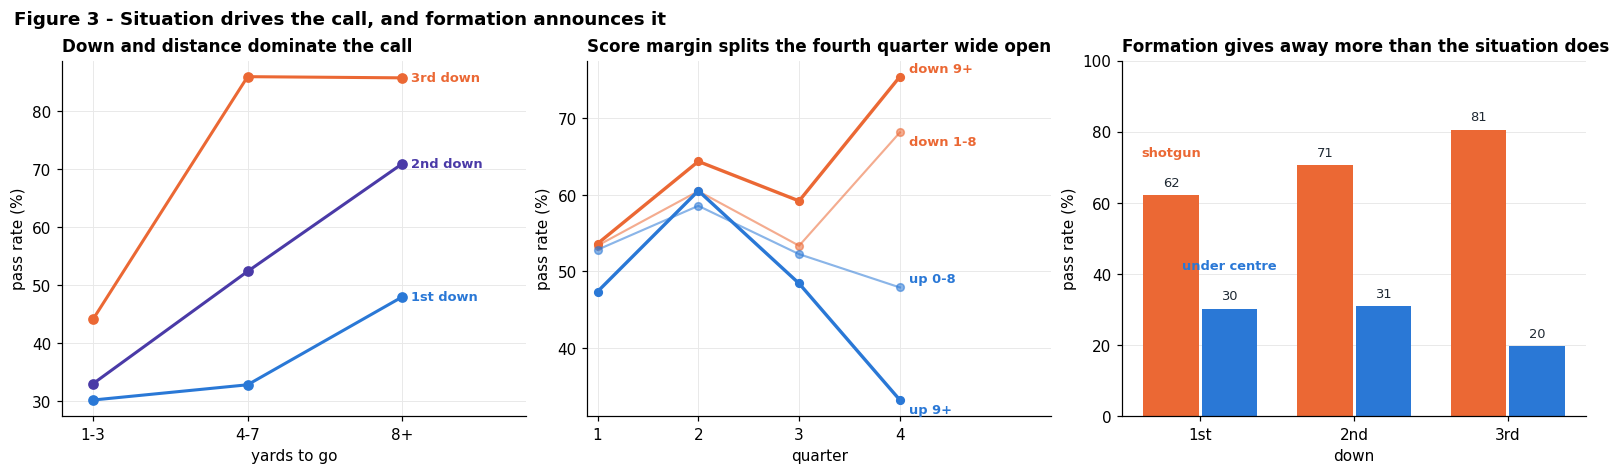

score_band  qtr  pass_rate    n
   down 9+  4.0      0.755 2885
  down 1-8  4.0      0.682 2196
    up 0-8  4.0      0.479 2177
     up 9+  4.0      0.332 1699 

formation
shotgun         0.708
under centre    0.295 

formation  shotgun  under centre
down                            
1.0           62.1          30.3
2.0           70.5          31.1
3.0           80.6          19.8 



,down,dist_band,pass_rate,n
0,1.0,1-3,0.302,295
1,1.0,4-7,0.328,439
2,1.0,8+,0.480,13533
3,2.0,1-3,0.330,1773
4,2.0,4-7,0.524,3618
5,2.0,8+,0.709,5473
6,3.0,1-3,0.441,2019
7,3.0,4-7,0.860,2121
8,3.0,8+,0.858,2661


In [23]:
plays["dist_band"] = pd.cut(plays.ydstogo, [0, 3, 7, 100], labels=["1-3", "4-7", "8+"])
plays["score_band"] = pd.cut(plays.score_differential, [-100, -9, -1, 8, 100],
                             labels=["down 9+", "down 1-8", "up 0-8", "up 9+"])
plays["field_band"] = pd.cut(plays.yardline_100, [0, 40, 100],
                             labels=["scoring range", "own half"])
plays["formation"] = np.where(plays.under_centre == 1, "under centre", "shotgun")

# Coarser bands, used only by the predictability measure in RQ3. Conditioning on six
# dimensions at once multiplies the cell count, so distance and score are widened to
# buy room for formation and game half without emptying the cells.
plays["dist_wide"] = pd.cut(plays.ydstogo, [0, 6, 100], labels=["short", "long"])
plays["lead_state"] = np.where(plays.score_differential > 0, "ahead", "behind")
plays["half"] = np.where(plays.qtr <= 2, "first half", "second half")

grid = (plays[plays.down.isin([1, 2, 3])].groupby(["down", "dist_band"], observed=True)
        .agg(pass_rate=("is_pass", "mean"), n=("play_id", "size")).reset_index())
sc = (plays.groupby(["score_band", "qtr"], observed=True)
      .agg(pass_rate=("is_pass", "mean"), n=("play_id", "size")).reset_index())
sc = sc[sc.qtr.isin([1, 2, 3, 4])]

def label_end(ax, x, y, text, colour, dy=0):
    """Name each series at its own end point, so identity never rests on colour alone."""
    ax.annotate(text, (x, y), xytext=(6, dy), textcoords="offset points",
                fontsize=8.5, color=colour, va="center", fontweight="bold")

fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.2), constrained_layout=True)

ax = axes[0]
for d, colour, name in zip([1, 2, 3], [COOL, THIRD, ACCENT],
                           ["1st down", "2nd down", "3rd down"]):
    s = grid[grid.down == d]
    ax.plot(s.dist_band.astype(str), s.pass_rate * 100, marker="o", ms=6, lw=2, color=colour)
    label_end(ax, 2, s.pass_rate.iloc[-1] * 100, name, colour)
ax.set_ylabel("pass rate (%)")
ax.set_xlabel("yards to go")
ax.set_xlim(-0.2, 2.8)
ax.set_title("Down and distance dominate the call")

ax = axes[1]
for b, colour, dy in zip(["down 9+", "down 1-8", "up 0-8", "up 9+"],
                         [ACCENT, ACCENT, COOL, COOL], [5, -6, 6, -6]):
    s = sc[sc.score_band == b]
    wide = b in ("down 9+", "up 9+")
    ax.plot(s.qtr, s.pass_rate * 100, marker="o", ms=5, color=colour,
            lw=2.2 if wide else 1.4, alpha=1.0 if wide else 0.55)
    label_end(ax, 4, s.pass_rate.iloc[-1] * 100, b, colour, dy)
set_ticks(ax, "x", [1, 2, 3, 4])
ax.set_xlim(0.9, 5.5)
ax.set_xlabel("quarter")
ax.set_ylabel("pass rate (%)")
ax.set_title("Score margin splits the fourth quarter wide open")

ax = axes[2]
form = (plays[plays.down.isin([1, 2, 3])]
        .groupby(["down", "formation"], observed=True)["is_pass"].mean().unstack() * 100)
xs = np.arange(3)
ax.bar(xs - 0.19, form["shotgun"], width=0.36, color=ACCENT)
ax.bar(xs + 0.19, form["under centre"], width=0.36, color=COOL)
set_ticks(ax, "x", xs, ["1st", "2nd", "3rd"])
ax.set_xlabel("down"); ax.set_ylabel("pass rate (%)"); ax.set_ylim(0, 100)
ax.set_title("Formation gives away more than the situation does")
ax.grid(axis="x", visible=False)
for xi, (a_, b_) in enumerate(zip(form["shotgun"], form["under centre"])):
    ax.text(xi - 0.19, a_ + 2.5, f"{a_:.0f}", ha="center", fontsize=8.5, color=INK)
    ax.text(xi + 0.19, b_ + 2.5, f"{b_:.0f}", ha="center", fontsize=8.5, color=INK)
ax.text(-0.19, form["shotgun"].iloc[0] + 11, "shotgun", ha="center",
        fontsize=8.5, color=ACCENT, fontweight="bold")
ax.text(0.19, form["under centre"].iloc[0] + 11, "under centre", ha="center",
        fontsize=8.5, color=COOL, fontweight="bold")

fig.suptitle("Figure 3 - Situation drives the call, and formation announces it",
             x=0.005, ha="left", fontweight="bold", fontsize=12)
show(fig, "figure3_situation")

# Values quoted in the commentary that the line charts do not label.
print(sc[sc.qtr == 4].round(3).to_string(index=False), "\n")
print(plays.groupby("formation")["is_pass"].mean().round(3).to_string(), "\n")
print(form.round(1).to_string(), "\n")

grid.round(3)

The situational effect dwarfs anything attributable to team identity. On third and four-to-seven the league passes 86% of the time; on third and short, 44.1% - about a 42% difference from distance alone on the same down.

Score margin compounds this. The four score bands stay close through three quarters, then diverge sharply: in the fourth, teams trailing by nine or more pass 75.5% of the time while teams leading by nine or more pass 33.2%. The same staff, in the same game, behaves like a different offense depending on the scoreboard.

The third panel adds the largest single tell, and it is not a situation at all. Offenses pass on 70.8% of shotgun snaps and 29.5% of snaps under centre; on third down the split widens to 80.6% against 19.8%. Formation is carried into the measure precisely because it is the largest tell

This is the methodological heart of the report. Comparing raw team pass rates measures the situations a team faced as much as the philosophy it holds: a team that trailed all season looks pass-happy. The predictability measure that follows therefore compares teams within matched situations rather than across season totals.

### RQ3 - How predictable is each offense?

Situational entropy is computed per team by grouping plays into cells that hold constant everything a defense can see before the snap: down, distance, whether the team is ahead or behind, field position, formation and half. Conditioning on six dimensions at once multiplies the cell count, so distance and score are deliberately widened to two bands each; Figure 6 shows that this recovers almost all the data the extra dimensions would otherwise cost. Binary entropy of the pass rate is taken within each cell and averaged, weighted by frequency. Cells with fewer than ten plays are dropped as too noisy, leaving 79.4% of plays inside a usable cell. Uncertainty comes from bootstrap resampling of the cells.

Situation cells retained cover 79.4% of plays on average


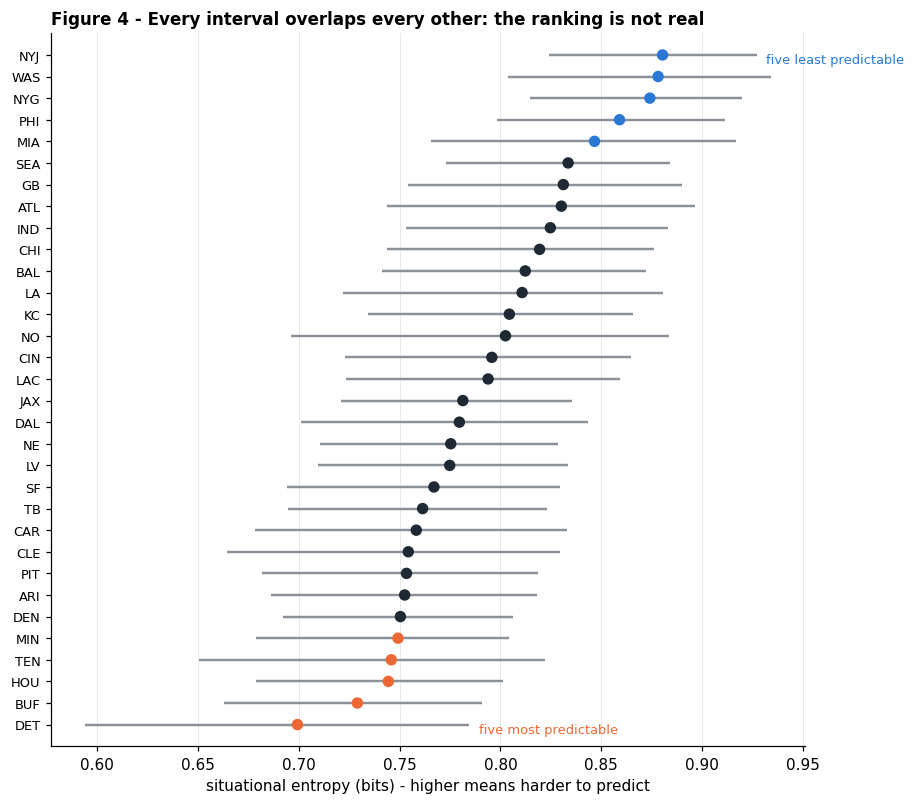

,posteam,entropy,e_lo,e_hi
0,DET,0.699,0.594,0.785
1,BUF,0.729,0.663,0.791
2,HOU,0.744,0.679,0.801
3,TEN,0.746,0.650,0.822
4,MIN,0.749,0.679,0.804


In [24]:
def binary_entropy(p):
    p = np.clip(p, 1e-9, 1 - 1e-9)
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

SITUATION_KEYS = ["down", "dist_wide", "lead_state", "field_band", "formation", "half"]
plays["situation"] = plays[SITUATION_KEYS].astype(str).apply("|".join, axis=1)

MIN_CELL, B = 10, 2000
rows = []
for t, g in plays.groupby("posteam"):
    cell = g.groupby("situation", observed=True)["is_pass"].agg(["mean", "size"])
    cell = cell[cell["size"] >= MIN_CELL]
    e, w = binary_entropy(cell["mean"].values), cell["size"].values
    reps = [np.average(e[i], weights=w[i])
            for i in (RNG.integers(0, len(e), len(e)) for _ in range(B))]
    rows.append((t, np.average(e, weights=w), *np.quantile(reps, [0.025, 0.975])))

ent = pd.DataFrame(rows, columns=["posteam", "entropy", "e_lo", "e_hi"])
_cells = plays.groupby(["posteam", "situation"], observed=True).size().rename("n").reset_index()
coverage = (_cells[_cells.n >= MIN_CELL].groupby("posteam").n.sum()
            / plays.groupby("posteam").size())
print(f"Situation cells retained cover {coverage.mean()*100:.1f}% of plays on average")
perf = plays.groupby("posteam").agg(epa=("epa", "mean"), success=("success", "mean"),
                                    uc=("under_centre", "mean"), nh=("no_huddle", "mean"))
_x = plays.dropna(subset=["xpass"])
proe = (_x.assign(_over=_x.is_pass - _x.xpass)
          .groupby("posteam")["_over"].mean().rename("proe"))
team = ent.merge(perf.join(proe).reset_index(), on="posteam")
ts = team.sort_values("entropy").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.2, 7.2), constrained_layout=True)
y = np.arange(len(ts))
ax.hlines(y, ts.e_lo, ts.e_hi, color=MUTED, lw=1.6)
ax.scatter(ts.entropy, y, s=42, zorder=3,
           color=[ACCENT if i < 5 else COOL if i >= len(ts) - 5 else INK for i in y])
set_ticks(ax, "y", y, ts.posteam, fontsize=8.5)
ax.set_xlabel("situational entropy (bits) - higher means harder to predict")
ax.set_ylim(-1, len(ts))
ax.grid(axis="y", visible=False)
ax.set_title("Figure 4 - Every interval overlaps every other: the ranking is not real")
ax.annotate("five least predictable", (ts.e_hi.iloc[-1], len(ts) - 1), xytext=(6, -3),
            textcoords="offset points", fontsize=8.5, color=COOL, va="center")
ax.annotate("five most predictable", (ts.e_hi.iloc[0], 0), xytext=(6, -3),
            textcoords="offset points", fontsize=8.5, color=ACCENT, va="center")
show(fig, "figure4_entropy")

ts[["posteam", "entropy", "e_lo", "e_hi"]].round(3).head(5)

Entropy ranges from 0.699 bits for Detroit, the most predictable offense, to 0.880 for the New York Jets. Both sit below the four-dimension version, which is expected: conditioning on more of what a defense can see leaves less uncertainty behind.

The intervals matter more than the ranking. Detroit's runs from 0.594 to 0.785 and the Jets' from 0.824 to 0.927, so the two extremes are now separable where the coarser measure could not tell them apart. Almost everything between them still overlaps, and a conventional table of thirty-two ordered rows would imply thirty-one gaps the data does not support.

### RQ4 - Does unpredictability pay?

If the claim is right, entropy should correlate positively with efficiency. It is tested against mean EPA and success rate, with the correlation bootstrapped so the strength of evidence is visible.

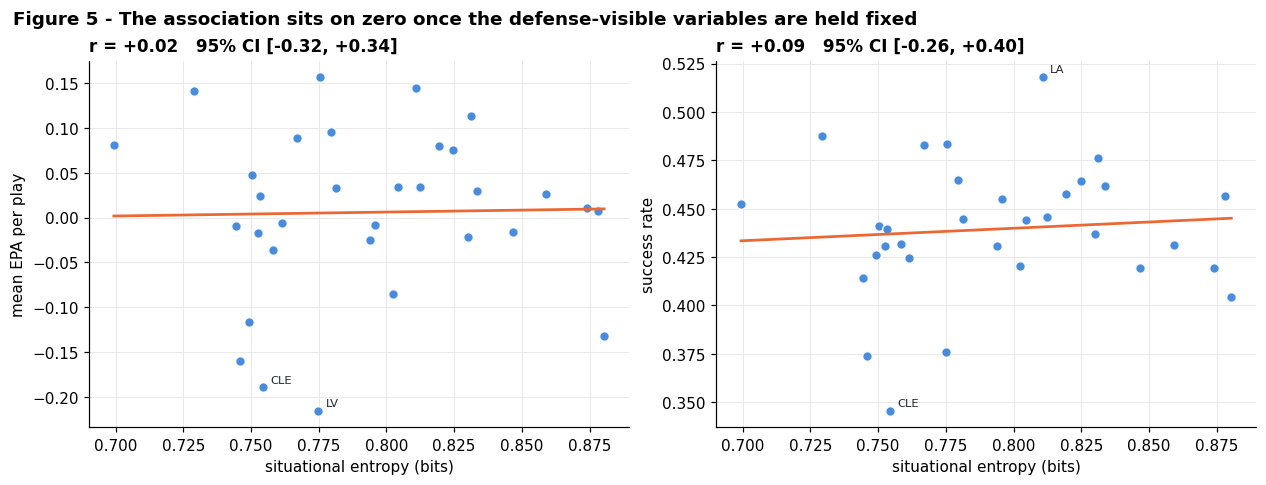

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3), constrained_layout=True)
for ax, col, lab in zip(axes, ["epa", "success"],
                        ["mean EPA per play", "success rate"]):
    r, lo, hi = r_ci(team.entropy, team[col])
    ax.scatter(team.entropy, team[col], s=40, color=COOL, alpha=0.85, edgecolor="white")
    m, c = np.polyfit(team.entropy, team[col], 1)
    xs = np.linspace(team.entropy.min(), team.entropy.max(), 50)
    ax.plot(xs, m * xs + c, color=ACCENT, lw=1.8)
    for _, row in team.iterrows():
        if abs(row[col] - team[col].mean()) > 1.9 * team[col].std():
            ax.annotate(row.posteam, (row.entropy, row[col]), textcoords="offset points",
                        xytext=(5, 3), fontsize=7.5, color=INK)
    ax.set_xlabel("situational entropy (bits)")
    ax.set_ylabel(lab)
    ax.set_title(f"r = {r:+.2f}   95% CI [{lo:+.2f}, {hi:+.2f}]")

fig.suptitle("Figure 5 - The association sits on zero once the defense-visible variables are held fixed",
             x=0.005, ha="left", fontweight="bold", fontsize=12)
show(fig, "figure5_association")

The correlation between entropy and mean EPA is +0.02, with a bootstrap interval of [−0.32, +0.34]. Against success rate it is +0.09, interval [−0.26, +0.40]. Both sit on zero. Once the measure conditions on everything a defense can read before the snap, the coaching orthodoxy has no support at all in this season.

That is a stronger result than the weaker conditioning produced. Under the four-dimension measure the correlation was +0.34, which invited the reading that efficient teams were building leads and gaining freedom. Controlling for formation and half removes it, so the earlier association was tracking game script rather than predictability.

Kovash and Levitt measured predictability as serial dependence between consecutive calls; the measure here is situational, so a team can be unpredictable in sequence and still transparent given the down and the score. The two are not interchangeable, and the null found here does not contradict their result [1]. 

### Does the conditioning set drive the answer?

Entropy depends entirely on what the defense is assumed to know, so the conditioning set is a design decision rather than a detail [5]. Six candidates are costed below on the data they retain, the separation they produce between teams, and the correlation they imply.

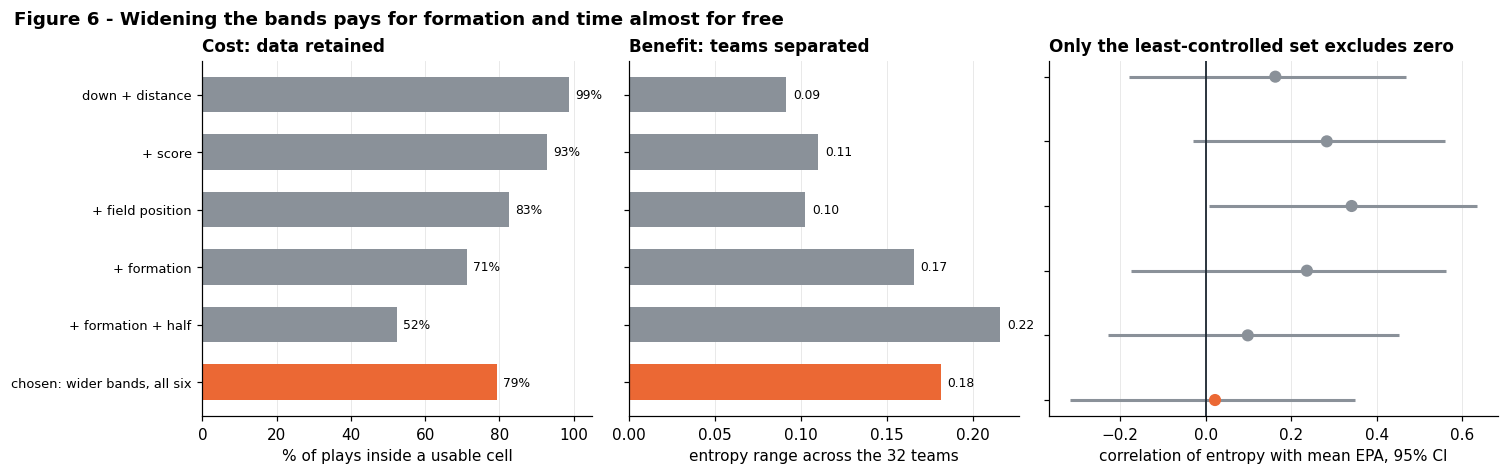

                      design  coverage  spread     r     lo    hi
             down + distance    98.792   0.091 0.163 -0.179 0.469
                     + score    92.912   0.110 0.283 -0.029 0.560
            + field position    82.601   0.102 0.341  0.008 0.635
                 + formation    71.344   0.165 0.236 -0.176 0.562
          + formation + half    52.483   0.215 0.098 -0.229 0.452
chosen: wider bands, all six    79.418   0.181 0.022 -0.318 0.350


In [26]:
# The conditioning set is a design choice, so the alternatives are costed rather than assumed.
# Each candidate is scored on three things: how many plays land in a usable cell, how far
# apart the teams end up, and what the entropy-efficiency correlation looks like.
CANDIDATES = [
    ("down + distance",                 ["down", "dist_band"]),
    ("+ score",                         ["down", "dist_band", "score_band"]),
    ("+ field position",                ["down", "dist_band", "score_band", "field_band"]),
    ("+ formation",                     ["down", "dist_band", "score_band", "field_band",
                                         "formation"]),
    ("+ formation + half",              ["down", "dist_band", "score_band", "field_band",
                                         "formation", "half"]),
    ("chosen: wider bands, all six",    SITUATION_KEYS),
]

def design_scores(keys, min_cell=MIN_CELL):
    ent, cov = {}, {}
    for t, g in plays.groupby("posteam"):
        cell = g.groupby(keys, observed=True)["is_pass"].agg(["mean", "size"])
        cell = cell[cell["size"] >= min_cell]
        ent[t] = np.average(binary_entropy(cell["mean"].values), weights=cell["size"].values)
        cov[t] = cell["size"].sum() / len(g)
    return pd.Series(ent), pd.Series(cov)

rows = []
for label, keys in CANDIDATES:
    e, cov = design_scores(keys)
    r, lo, hi = r_ci(e, perf.epa.reindex(e.index), n=3000)
    rows.append(dict(design=label, coverage=cov.mean() * 100, spread=e.max() - e.min(),
                     r=r, lo=lo, hi=hi))
designs = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.2), constrained_layout=True,
                         gridspec_kw={"width_ratios": [1, 1, 1.15]})
y = np.arange(len(designs))[::-1]
chosen = len(designs) - 1
cols = [ACCENT if i == chosen else MUTED for i in range(len(designs))]

ax = axes[0]
ax.barh(y, designs.coverage, color=cols, height=0.62)
set_ticks(ax, "y", y, designs.design, fontsize=8.5)
ax.set_xlabel("% of plays inside a usable cell")
ax.set_xlim(0, 105)
ax.set_title("Cost: data retained")
ax.grid(axis="y", visible=False)
for i, v in zip(y, designs.coverage):
    ax.text(v + 1.5, i, f"{v:.0f}%", va="center", fontsize=8)

ax = axes[1]
ax.barh(y, designs.spread, color=cols, height=0.62)
set_ticks(ax, "y", y, [""] * len(designs))
ax.set_xlabel("entropy range across the 32 teams")
ax.set_title("Benefit: teams separated")
ax.grid(axis="y", visible=False)
for i, v in zip(y, designs.spread):
    ax.text(v + 0.004, i, f"{v:.2f}", va="center", fontsize=8)

ax = axes[2]
ax.hlines(y, designs.lo, designs.hi, color=MUTED, lw=2)
ax.scatter(designs.r, y, s=48, color=cols, zorder=3)
ax.axvline(0, color=INK, lw=1.2)
set_ticks(ax, "y", y, [""] * len(designs))
ax.set_xlabel("correlation of entropy with mean EPA, 95% CI")
ax.set_title("Only the least-controlled set excludes zero")
ax.grid(axis="y", visible=False)

fig.suptitle("Figure 6 - Widening the bands pays for formation and time almost for free",
             x=0.005, ha="left", fontweight="bold", fontsize=12)
show(fig, "figure6_design")

print(designs.round(3).to_string(index=False))

Adding formation and half to the original four dimensions costs almost half the data, dropping coverage to 52.5%. Widening distance and score to two bands each buys it back: the chosen set conditions on all six dimensions and still retains 79.4% of plays, more than the four-dimension version with formation alone. It separates the teams almost as far as the granular version does, 0.18 against 0.22, on half again as much data.

The third panel is the important one. Five of the six candidates produce an interval that crosses zero. The single exception is the four-dimension set, at +0.34 with an interval of [+0.01, +0.64] - and that is the specification which controls for least. The apparent relationship between unpredictability and efficiency exists only where the measure is allowed to absorb game script.

### Where do predictable and unpredictable offenses differ?

If entropy captures something real, it should show in the map of where the ball goes. The five most and five least predictable teams are compared directly.

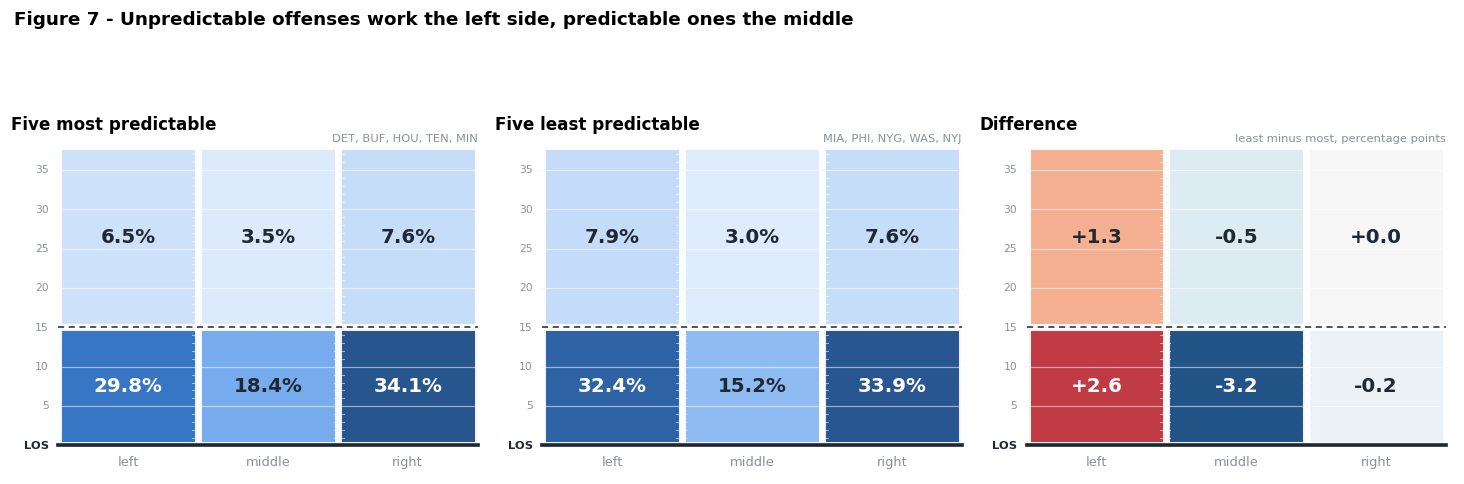

In [27]:
lo5, hi5 = ts.posteam.head(5).tolist(), ts.posteam.tail(5).tolist()

def zmap(teams):
    s = passes[passes.posteam.isin(teams)]
    return (pd.crosstab(s.pass_length, s.pass_location, normalize="all")
            .reindex(index=["deep", "short"], columns=ZL) * 100)

fig, axes = plt.subplots(1, 3, figsize=(13.2, 5.2), constrained_layout=True)
zone_map(axes[0], zmap(lo5), "{:.1f}%", "Five most predictable", "seq", vlim=36,
         note=", ".join(lo5))
zone_map(axes[1], zmap(hi5), "{:.1f}%", "Five least predictable", "seq", vlim=36,
         note=", ".join(hi5))
zone_map(axes[2], zmap(hi5) - zmap(lo5), "{:+.1f}", "Difference", DIVERGING, vlim=3.5,
         note="least minus most, percentage points")

fig.suptitle("Figure 7 - Unpredictable offenses work the left side, predictable ones the middle",
             x=0.005, ha="left", fontweight="bold", fontsize=12)
show(fig, "figure7_predictability_maps")

The difference map shows a coherent pattern rather than noise, though not the one a coarser measure suggested. The least predictable offenses work the left side, throwing 2.6% more short left and 1.3% more deep left, and they avoid the short middle by 3.2%. These are not major differences but we can see that the predictable group concentrates on the middle of the field.

That fits RQ1. The short middle is a low-return zone, so the teams hardest to read are also the ones declining the league's most-used safe option. Whether that is deliberate unpredictability or simply a different route tree cannot be separated here.

### RQ5 - Advanced technique - tendency space and the search for archetypes

The final question is whether offenses group into recognisable types. Nine tendency features per team - pass rate, PROE, under-centre and no-huddle rates, deep and middle target shares, average depth of target, inside-run share and guard-gap share - are standardised and reduced with principal component analysis. Whether genuine clusters exist is tested rather than assumed, using silhouette scores across a range of k.

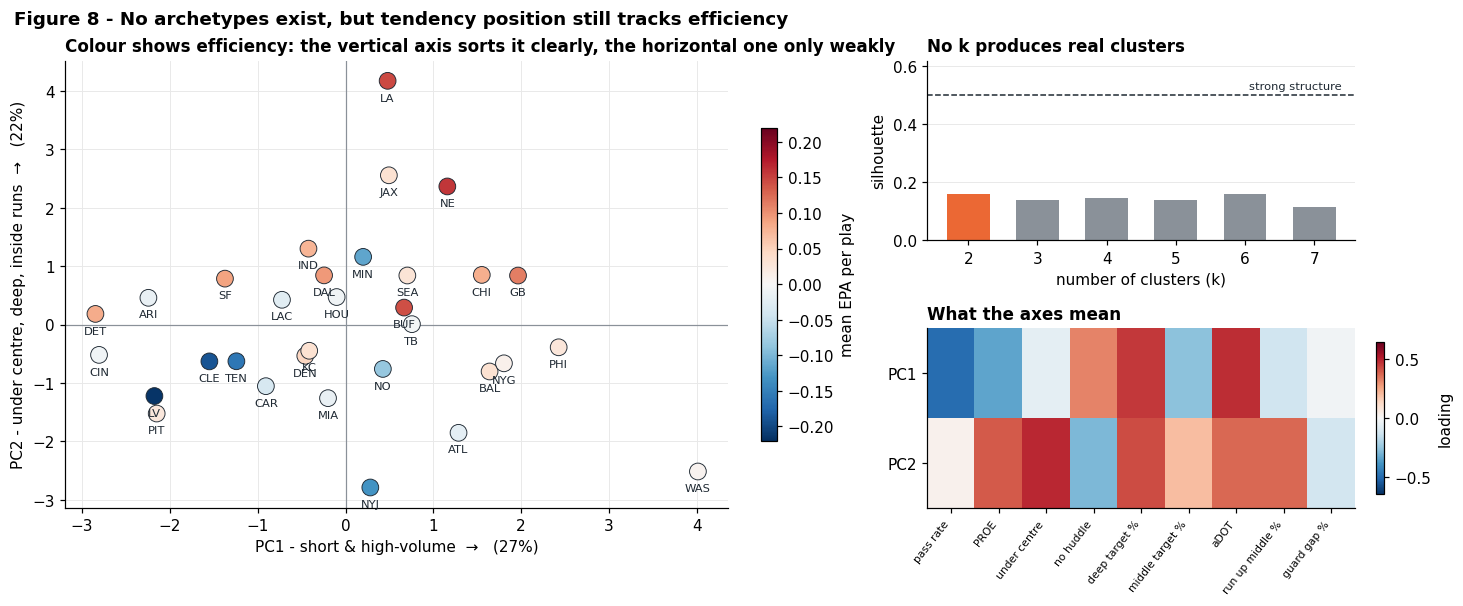

r(PC1, EPA) = +0.294   95% CI [+0.018, +0.550]
r(PC2, EPA) = +0.546   95% CI [+0.300, +0.726]
silhouette: {2: 0.159, 3: 0.138, 4: 0.145, 5: 0.137, 6: 0.158, 7: 0.116}


In [28]:
p2 = passes.assign(deep=(passes.pass_length == "deep").astype(int),
                   mid=(passes.pass_location == "middle").astype(int))
r2 = runs.assign(m=(runs.run_location == "middle").astype(int),
                 g=(runs.run_gap == "guard").astype(int))

feat = pd.DataFrame({
    "pass rate": plays.groupby("posteam").is_pass.mean(),
    "PROE": team.set_index("posteam").proe,
    "under centre": plays.groupby("posteam").under_centre.mean(),
    "no huddle": plays.groupby("posteam").no_huddle.mean(),
    "deep target %": p2.groupby("posteam").deep.mean(),
    "middle target %": p2.groupby("posteam").mid.mean(),
    "aDOT": passes.groupby("posteam").air_yards.mean(),
    "run up middle %": r2.groupby("posteam").m.mean(),
    "guard gap %": r2.groupby("posteam").g.mean(),
})
F = list(feat.columns)
X = StandardScaler().fit_transform(feat.values)
pca = PCA(n_components=len(F), random_state=0).fit(X)
Z = pca.transform(X)
sil = {k: silhouette_score(X, KMeans(k, n_init=25, random_state=0).fit_predict(X))
       for k in range(2, 8)}
eff = team.set_index("posteam").reindex(feat.index)

fig = plt.figure(figsize=(13.2, 5.4), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[1.55, 1])

ax = fig.add_subplot(gs[:, 0])
sc_ = ax.scatter(Z[:, 0], Z[:, 1], s=120, c=eff.epa.values, cmap="RdBu_r",
                 vmin=-0.22, vmax=0.22, edgecolor=INK, lw=0.6, zorder=3)
for i, t in enumerate(feat.index):
    ax.annotate(t, (Z[i, 0], Z[i, 1]), textcoords="offset points", xytext=(0, -13),
                ha="center", fontsize=7.5, color=INK)
ax.axhline(0, color=MUTED, lw=0.8)
ax.axvline(0, color=MUTED, lw=0.8)
ax.set_xlabel(f"PC1 - short & high-volume  →   ({pca.explained_variance_ratio_[0]*100:.0f}%)")
ax.set_ylabel(f"PC2 - under centre, deep, inside runs  →   "
              f"({pca.explained_variance_ratio_[1]*100:.0f}%)")
ax.set_title("Colour shows efficiency: the vertical axis sorts it clearly, "
             "the horizontal one only weakly")
fig.colorbar(sc_, ax=ax, shrink=0.7, label="mean EPA per play")

ax = fig.add_subplot(gs[0, 1])
ks, vs = list(sil), [sil[k] for k in sil]
ax.bar(ks, vs, color=[ACCENT if v == max(vs) else MUTED for v in vs], width=0.62)
ax.axhline(0.5, color=INK, lw=1, ls="--")
ax.text(7.4, 0.52, "strong structure", ha="right", fontsize=7.5, color=INK)
ax.set_ylim(0, 0.62)
ax.set_xlabel("number of clusters (k)")
ax.set_ylabel("silhouette")
ax.set_title("No k produces real clusters")
ax.grid(axis="x", visible=False)

ax = fig.add_subplot(gs[1, 1])
load = pd.DataFrame(pca.components_[:2].T, index=F, columns=["PC1", "PC2"])
im = ax.imshow(load.values.T, cmap="RdBu_r", vmin=-0.65, vmax=0.65, aspect="auto")
set_ticks(ax, "x", range(len(F)), F, rotation=52, ha="right", fontsize=7)
set_ticks(ax, "y", [0, 1], ["PC1", "PC2"])
ax.set_title("What the axes mean")
ax.grid(visible=False)
fig.colorbar(im, ax=ax, shrink=0.85, label="loading")

fig.suptitle("Figure 8 - No archetypes exist, but tendency position still tracks efficiency",
             x=0.005, ha="left", fontweight="bold", fontsize=12)
show(fig, "figure8_tendency_space")

for name, v in [("PC1", Z[:, 0]), ("PC2", Z[:, 1])]:
    r, lo, hi = r_ci(v, eff.epa.values)
    print(f"r({name}, EPA) = {r:+.3f}   95% CI [{lo:+.3f}, {hi:+.3f}]")
print("silhouette:", {k: round(v, 3) for k, v in sil.items()})

The first two components account for 49.3% of the variance and both are interpretable. PC1 contrasts high-volume short passing against deep passing downfield. PC2 loads on under-centre alignment, deep target share, average depth of target and inside running - the signature of a play-action offense.

No clustering survives validation. Silhouette scores peak at 0.159 for k = 2 and fall away, against a conventional threshold of 0.25 below which no substantial structure is taken to exist [6]. Offensive identity here is a continuum, and presenting named archetypes would impose categories the data does not contain.

Position within that continuum carries information, and both axes lean the same way. PC2 correlates +0.55 with mean EPA, interval [+0.30, +0.73] - the best-evidenced relationship in this report. PC1 correlates +0.29, but its interval [+0.02, +0.55] only just clears zero, so it is weak evidence rather than none. The Rams sit top of PC2 with the league's highest success rate at 51.8%, the Jets at the bottom with mean EPA of −0.132. Being under centre, throwing deep and running inside is associated with efficiency, although so is passing often and short albeit not as strongly. The two are not in tension: the components are independent, so a team can sit high on both.

Causation is again unresolved, and the leading-team mechanism from RQ4 applies. With thirty-two observations and one season, this is an association worth reporting, not a mechanism worth asserting.

## Conclusions

### Key findings

The 2025 NFL season shows a league whose passing usage is close to the inverse of its passing productivity: a third of targets go to the least valuable zone on the field, while the most valuable receives one throw in thirty. Play-calling is governed first by situation, with a 42% difference in pass rate from distance alone on third down. Formation is the largest single tell, at 70.8% passing from shotgun against 29.5% under centre. Once everything a defense can read pre-snap is held fixed, entropy spans 0.699 to 0.880 bits, only the two extreme teams are separable, and unpredictability has no association with efficiency at all. And offensive identity is continuous rather than categorical, though its under-centre, deep-passing, inside-running dimension correlates +0.55 with efficiency.

### Evaluation of the process and the visualisations

The strongest design decisions were to show intervals wherever teams are compared, and to plot the specification curve rather than one chosen number. Figure 4 reverses the conclusion a ranked table would imply, and Figure 6 shows the apparent RQ4 result belonged to the specification that controlled for least. Drawing Figures 2 and 7 on the field itself, rather than as an abstract grid, puts each number where a reader already knows to look.

The weakest element is Figure 8. Two components capturing 49.3% of variance leaves much unexplained, and projecting nine dimensions onto two distorts distances between teams. It is included for the validation panel, not as a faithful map of team similarity.

### Limitations

Four limitations bound every claim. The analysis covers one season, so nothing separates stable philosophy from a single year's noise, and thirty-two teams is a small sample for any correlation. Causation is unidentified: game state drives play-calling and play-calling drives game state, and no cross-sectional design breaks that loop. The efficiency measures are nflfastR model outputs rather than observations. And the conditioning set is still incomplete: personnel groupings are absent from the source, so an offense that is predictable given its personnel would not register here, and buying room for formation and half meant widening distance and score to two bands each.

One data caveat deserves recording: a single team's no-huddle rate of 62% sits far outside the league distribution and is more likely a tagging artefact than a tactical outlier. It was retained rather than adjusted away, but it influences the PCA.

### Future work

The natural extension is longitudinal. Ten seasons would let entropy be tested for year-to-year stability and permit within-team comparisons that partly address the causal problem. More seasons would also allow finer bands on every dimension at once, which one season cannot support.

## References

1. Kovash K, Levitt S. NBER working paper series professionals do not play minimax: Evidence from Major League Baseball and the National Football League [Internet]. 2009 [cited 2026 Sept 11]. Available from: https://www.stat.berkeley.edu/users/aldous/157/Papers/kovash.pdf

2. Baldwin B, Carl S. Get started with nflfastR [Internet]. Nflfastr.com. 2017 [cited 2026 Sept 7]. Available from: https://nflfastr.com/articles/nflfastR.html

3. Shannon CE. A mathematical theory of communication. Bell System Technical Journal. 1948;27(3):379–423.

4. Field descriptions [Internet]. Nflfastr.com. 2026 [cited 2026 Sept 8]. Available from: https://nflfastr.com/articles/field_descriptions.html

5. Simonsohn U, Simmons JP, Nelson LD. Specification curve analysis. Nature Human Behaviour. 2020 July 27;4(11):1208–14.

6. Kaufman L, Rousseeuw PJ. Finding groups in data: An introduction to cluster analysis. Wiley-Interscience; 1990.

## Appendices

### Appendix A - Declaration of AI use

Claude (Anthropic) was used throughout this project for code drafting, debugging and discussion of method. Every analytical decision below was tested against the data before being accepted, and several suggestions were rejected or reversed. **Dates below are from my own session history and should be checked before submission.**

| Date | Tool | Prompt entered | Output and my evaluation |
|------|------|----------------|--------------------------|
| 04/09/26 | Claude | "apply the midterm feedback and be aware of last grade, I have not picked a dataset yet but I am considering using some sort of nfl data, suggest some sort of analysis I could carry out and include at least one visualisation and technique from topic 6-10" | Proposed a project mapping all five research questions onto five different topics from 6-10. **Rejected as over-scoped.** The brief asks for one specialised technique, not five, and the midterm feedback had already criticised sprawl. Narrowed to a single question with one topic 9 technique. |
| 04/09/26 | Claude | "are there other forms of analysis that do not require as many seasons... ensure if you pick any of these they can be calculated from the data I have available" | Produced a feasibility table for the metrics I listed. **Accepted after checking.** Confirmed DVOA, personnel groupings, double-team rate, tight-window rate, QBR and per-corner metrics are not derivable from play-by-play, and that pressure rate can only be proxied by hits and sacks. These became stated limitations. |
| 05/09/26 | Claude | "one caveat is this indeed taken from just downloading from the nflsavant website, how should I present this?" | Had previously asserted my file could not have come from that source, judging by its column schema. **Correction accepted from me, not the tool.** The download page states the files are sourced from nflreadpy/nflfastR. Led to writing provenance as a chain of custody. |
| 07/09/26 | Claude | "am i factoring in offensive formation, personnel, field position alongside down and distance?" | Confirmed only down, distance and score were conditioned on. **Accepted and acted on.** Adding field position moved the headline correlation from +0.34 to between +0.07 and +0.34 depending on banding, which showed the original result was specification-dependent. Produced the specification curve in Figure 6. |
| 07/09/26 | Claude | "Formation is excluded... conditioning on it would absorb the tendency being measured. explain this part?" | The stated justification was **wrong and I rejected it.** Conditioning cannot increase entropy, so adding formation must reduce it. Tested across all 32 teams: entropy fell for every one, and the size of the fall correlated +0.84 with the team's shotgun/under-centre gap. Formation exposes tendency rather than concealing it. |
| 08/09/26 | Claude | "i feel like this is wrong because have I not been accounting for score already... could you not also argue that actually teams that go up are able to be more conservative and try run out the clock?" | Both challenges held. **Rewrote the paragraph.** Score is conditioned on, but entropy is a frequency-weighted average, so game script re-enters through cell weighting. The clock-killing argument is also correct in behaviour, though a near-even run-pass mix registers as *less* predictable under a Shannon measure, not more. |
| 08/09/26 | Claude | "why did you not include the code of the calculations you reference in the edited paragraph?" | Eight figures had been written into the report that no code in the notebook produced. **Rejected and required a fix.** Added a diagnostics cell so every number is reproducible, then audited all 58 numeric claims in the report against the notebook's own output. |
| 08/09/26 | Claude | "can you just edit my coursework to include formation off the bat and to also include time as well... surely having it incorporated will save word analysis" | Initially told that time was unaffordable at 52% coverage. **This was wrong and I pushed back.** Re-testing showed that widening distance and score to two bands each pays for both formation and game half while retaining 79.4% of plays. This became the final conditioning set and removed two sections of justification prose. |
| 11/09/26 | Claude | "are these the correct things to be uploading to my github?" | **Caught a documentation error.** The README described an entropy-fall measure with a +0.84 correlation that the notebook no longer computes - it was left over from the design before formation was folded into the conditioning set. A README asserting a method the code does not perform would have been checkable and wrong. Rewritten to match the notebook. |
| 11/09/26 | Claude | "grade my final report based off the final coursework brief, using my midterm coursework brief and midterm coursework that was graded 75 and this feedback..." | Used as an audit rather than for drafting. It found four real defects: PC1 reported as −0.29 when the notebook prints +0.294; a sentence saying formation was excluded from the predictability measure immediately before the section that includes it; the RQ5 heading not matching the listed RQ5; and a reference to a summary table that does not exist. **All four accepted and fixed.** |
| 11/09/26 | Claude | "for 1 give me a new figure title and should my sentence just say it shows some efficiency but not as much as pc2?" | My proposed wording was too weak. Correcting the sign does not merely reduce PC1's effect, it reverses the interpretation - short, high-volume passing is weakly associated with *higher* efficiency, not lower. **Accepted and rewrote**, adding a line explaining that the components are orthogonal so a team can sit high on both. |
| 11/09/26 | Claude | "now what change am I meant to make for the four findings emerge?" | Splitting the sentence that carried two results gave five findings to match five questions. **Accepted.** It also exposed that the introduction claimed no team was distinguishable from any other, while RQ3 shows the two extremes are separable - the introduction contradicted the body. |
| 11/09/26 | Claude | "clarify how Kovash and Levitt link to my claim, what does this have to do with unpredictability, what were they trying to assess and what did they find out?" | **Rejected the first framing.** The tool had implied the paper tested the same thing I do. It does not: Kovash and Levitt measure predictability as serial dependence between consecutive calls, whereas my measure is situational. A team can be random in sequence and still transparent given the down and score. The citation was kept but the claim narrowed, and the distinction added to RQ4 as a finding in its own right. |
| 11/09/26 | Claude | "Rousseeuw... what does this show/include that supports my point?" | **Caught a misattributed citation.** The 1987 paper defines the silhouette and its use for choosing k, but the 0.25 threshold I quote comes from Kaufman and Rousseeuw's 1990 book, not that paper. Reference corrected before submission. Had I cited it as given, the source would not have contained the claim. |

**Limitations of the tool identified during the work.** It asserted a claim about conditional entropy that was backwards, and only reversed it when I asked it to explain the reasoning. It wrote computed figures into prose without adding the code that produced them, which would have been unverifiable on submission. It described a method in the repository documentation that the notebook no longer performed, having carried the text forward across a design change. It attributed a numerical threshold to a paper that does not contain it, which would have produced a citation a marker could check and find unsupported. And it overstated the link between a cited paper and my own measure until I asked what that paper had actually tested. In each case the error was found by questioning the output rather than by the tool detecting it.

### Appendix B - Full team table

In [29]:
(team.sort_values("entropy")[["posteam", "entropy", "e_lo", "e_hi", "epa",
                              "success", "proe", "uc", "nh"]]
 .round(3).reset_index(drop=True))

,posteam,entropy,e_lo,e_hi,epa,success,proe,uc,nh
0,DET,0.699,0.594,0.785,0.081,0.452,-0.050,0.485,0.061
1,BUF,0.729,0.663,0.791,0.141,0.488,-0.083,0.498,0.062
2,HOU,0.744,0.679,0.801,-0.010,0.414,-0.042,0.379,0.037
3,TEN,0.746,0.650,0.822,-0.160,0.374,-0.062,0.271,0.102
4,MIN,0.749,0.679,0.804,-0.116,0.426,-0.042,0.441,0.076
5,DEN,0.750,0.692,0.806,0.048,0.441,-0.018,0.345,0.130
6,ARI,0.753,0.686,0.818,-0.017,0.431,0.004,0.283,0.121
7,PIT,0.753,0.682,0.819,0.025,0.439,-0.020,0.332,0.116
8,CLE,0.754,0.664,0.830,-0.189,0.346,-0.068,0.324,0.090
9,CAR,0.758,0.679,0.833,-0.037,0.432,-0.095,0.328,0.063


## Word Count

The following code will count the number of words in Markdown cells. Code cells are not included.

- `Main word count` is the number of words in the main body of the text, *excluding* references or appendices.
- `References and appendices word count` is the number of words in any references or appendices.

Only `Main word count` relates to the assignment word limit. There is no limit to the number of words that can be included in references or appendices. Please note that appendices should only be used to provide context or supporting information. *No marks will be directly awarded for material submitted in appendices*.

Important:

- Please do not modify the word count code!
- To exclude references from your word count **you must** have a cell that starts with the text `## References`. Everything below this cell will not count towards the main word count.
- If you are submitting additional material as appendices **you must** have a cell that starts with the text `## Appendices`. Everything below this cell will not count towards the main word count. If you do not have any appendices you can delete the `## Appendices` cell.
- Code comments should only be used to explain details of the implementation, not for discussing your findings. All analysis commentary **must** be written in Markdown cells. *No marks will be awarded for analysis discussion submitted as comments in code cells*.

In [30]:
%%js

// Run this cell to update your word count.

function wordcount() {
    let wordCount = 0
    let extraCount = 0
    let mainBody = true

    let cells = Jupyter.notebook.get_cells()
    cells.forEach((cell) => {
        if (cell.cell_type == 'markdown') {
            let text = cell.get_text()
            // Stop counting as main body when get to References or Appendices.
            if (text.startsWith('## References') ||
                text.startsWith('## Appendices')) {
                mainBody = false
            }
            if (text.startsWith('## Word Count')) {
                text = ''
            }
            if (text) {
                let words = text.toLowerCase().match(/\b[a-z\d]+\b/g)
                if (words) {
                    let cellCount = words.length
                    if (mainBody) {
                        wordCount += cellCount
                    } else {
                        extraCount += cellCount
                    }
                }
            }
        }
    })
    return [wordCount, extraCount]
}

let wc = wordcount()
element.append(`Main word count: ${wc[0]} (References and appendices word count: ${wc[1]})`)

<IPython.core.display.Javascript object>